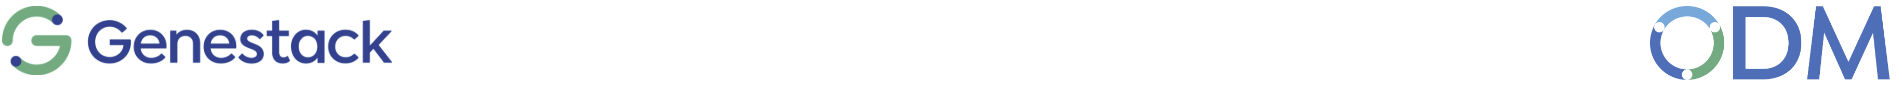

# From Single-Cell Data To Rare Cell Type Identification

**This Notebook is designed to introduce you to the Single-Cell Module in ODM and to show several possible applications of the features it has.** Newly added analytical queries enable users to quickly test hypotheses directly in ODM without downloading heavy data files.

**With this Notebook and the harmonised ODM instance users will be able:**
- To filter queries by any metadata fields
- To explore cell type heterogeneity
- To find cell-type specific genes
- To calculate cell ratios and single-cell differential expression server-side by filling in the filters in the Notebook
- To score another dataset with the resulting marker panel and relate that score to clinical metadata

This example covers a literature-derived case of the rare cell type identification and characterization in intestinal samples of patients with Crohn's disease yet the prepared instance contains other inflammatory conditions that can be investigated too.

## We hope that this example will inspire you to further explore the capabilities of the Single-Cell Module and to test your own hypotheses.

**Contact:** support@genestack.com &nbsp;·&nbsp; © 2026 Genestack.

---

## Prerequisites

### Installation

From the unzipped demo folder (the directory that contains `setup.py` and `demo_utils/`), install the local helper package and dependencies into the active notebook kernel.

In [1]:
from pathlib import Path
from importlib.metadata import distribution

ROOT = Path.cwd() # or Path('/path/to/demo/folder')

try:
    distribution('demo_utils')
    print('demo_utils already installed')
except Exception:
    %pip install -e "{ROOT}"

demo_utils already installed


Alternatively, you can install the dependencies into the Python environment (must be the same as the notebook kernel) via the terminal command:
```bash
python -m pip install -e .
```

### Imports
This subsection imports needed modules and packages.

In [2]:
# standard libraries (come with Python)
import os
import warnings
import contextlib

# third-party libraries (require installation)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Genestack ODM API (comes with odm-sdk)
import odm_api
from odm_api.models.cr_request import CRRequest
from odm_api.models.de_request_case_group import DERequestCaseGroup
from odm_api.models.de_request import DERequest

# local helper functions
from demo_utils import (
    
    # connection / instrumentation
    set_api_configuration,
    odm_timer,

    # shared utilities
    get_all_data,
    camel_case_keys,
    display_collapsible_table,

    # step 1 - explore cohort metadata
    display_metadata_summary,
    plot_metadata_summary,

    # step 2 - explore cell metadata and embeddings
    plot_cell_type_proportions_comparison,
    create_anndata_object,
    plot_umap_panel,

    # step 3 - explore rare cell type-specific genes
    plot_sc_dotplot_and_cell_summary,
    clean_expression_metadata,
    create_full_matrix,
    compare_gene_expression_with_umap,

    # step 4 - functional characterisation of rare cell type
    run_gsea_per_cell_type,
    plot_gsea_bubble,

    # step 5 - find similar cells in another dataset
    annotate_cells_by_marker_panel,
    plot_correlation_scatter
)

# local settings
plt.style.use('default')
warnings.filterwarnings('ignore', category=FutureWarning)

### Authentication
Run this cell to set ODM API credentials. Either enter your ODM token manually in the interactive form, or store it in a `.env` file as `ODM_API_TOKEN=...`.

If Azure authentication is available for your account, instead set `use_azure_auth=True` in `set_api_configuration` and sign in through the **interactive browser-based Microsoft Azure authentication**.

In [3]:
server = 'https://single-cell-evaluation.dev.gs.team'

api_client = set_api_configuration(server, use_azure_auth=False)

'ODM_API_TOKEN' not found in environment or .env. Falling back to manual input.
Token authentication successful! Docs: https://single-cell-evaluation.dev.gs.team/user-docs/tools/odm-api/python/generated/


## What can be done with this Notebook

Main question: *Can we discover and characterize a rare or poorly annotated cell population using ODM’s single-cell analytical queries — then recover that state in another study and relate it to clinical metadata — without downloading full expression matrices?*

1. **Select a cohort:** Focus on one study and filter disease, tissue, and assay.
2. **Explore cell space:** Inspect cell-type composition and UMAP embeddings for case and control. Use embedding coordinates as a cell query to define a candidate rare subtype.
3. **Find subtype-specific genes:** Rank markers with differential expression / specificity scoring, then keep a compact panel that is specific versus other named types.
4. **Characterize function:** Run pathway enrichment on specificity-ranked genes and compare with the authors’ fine annotation.
5. **Transfer the panel:** Score cells in an independent dataset with the same marker panel, check which finely labelled subtypes light up, and correlate the per-sample panel score with clinico-pathological parameters.


Most analytical steps query ODM live. The blue **⏱ timers** show query running time.

---
Expected result of this demo is a marker-defined rare subtype (here, inflammatory epithelial cells or INFLARE population that separates on UMAP) that can be linked back to literature / author labels in the discovery study and maps onto a named epithelial state plus clinical context in a second dataset.

## Step 1 · Cohort selection

**Which study and sample filters define a clean case–control single-cell cohort for rare-cell discovery?**

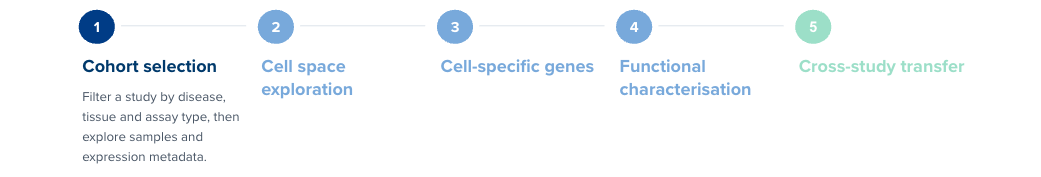

### 1.1 Select sample filters

This demo uses the small-intestine arm of *Single-cell integration reveals metaplasia in inflammatory gut diseases*, comparing **Crohn's disease** vs **Healthy**.

All the sample query parameters are defined once — study filter, disease terms, tissue, and assay. The rest of the notebook reuses `case_query_params` / `control_query_params` for metadata, cell, and analytical queries.

In [4]:
# define study filter
study_title = 'Single-cell integration reveals metaplasia in inflammatory gut diseases (Small intestine)'
study_filter = f'"Study Title"="{study_title}"'

# define disease terms
case_disease_term = 'Crohn\'s disease'
control_disease_term = 'Healthy'

# define tissue filter
tissue_term = 'small intestine'
tissue_filter = f'"Tissue General"="{tissue_term}"'

# exclude control samples
disease_condition_filter = ' AND '.join([
    '"Condition Group"!="control"',
    '"Condition Group"!="paired_control"',
])

# define age filter
age_filter = '"Developmental Stage"="human adult stage"'

# define library filter
library_filter = '"Assay Type"="scRNA-seq"'

# define query parameters for case and control samples
case_query_params = {
    'study_filter': study_filter,
    'sample_filter': ' AND '.join([
        f'Disease="{case_disease_term}"',
        f'({tissue_filter})',
        f'({disease_condition_filter})',
        f'({age_filter})'
    ]),
    'library_filter': library_filter
}
control_query_params = {
    'study_filter': study_filter,
    'sample_filter': ' AND '.join([
        f'Disease="{control_disease_term}"',
        f'({tissue_filter})',
        f'({age_filter})'
    ]),
    'library_filter': library_filter
}

### 1.2 Explore sample metadata

Pull biosample metadata for the filtered case and control groups, then summarise continuous and categorical fields. This is a quick sanity check that the cohort contains the expected diseases, tissues, and donor diversity before cell-level analysis.

,not_na,total,mean,median,std_dev,min,max
Donor Age,20,167,53.3,50.0,19.05,31.0,87.0


,not_na,unique,total,top_values
Cell Source,167,1,167,tissue
Condition Group,167,2,167,control / crohns_disease
Developmental Stage,167,1,167,human adult stage
Disease,167,2,167,Healthy / Crohn's disease
Donor Age Group,141,4,167,55-74 / 35-54 / 18-34 / 75+
Donor Age Range,125,6,167,60-70 / 50-60 / 20-30 / 40-50 / 30-40 / ...
Donor Age Unit,145,1,167,year
Donor Disease,167,3,167,CD / organ_donor / control
Donor ID,167,52,167,A34 (417C) / A66_759B / A38 (432C) / 403C / A39 (440C) / ...
Donor Sex,145,2,167,male / female


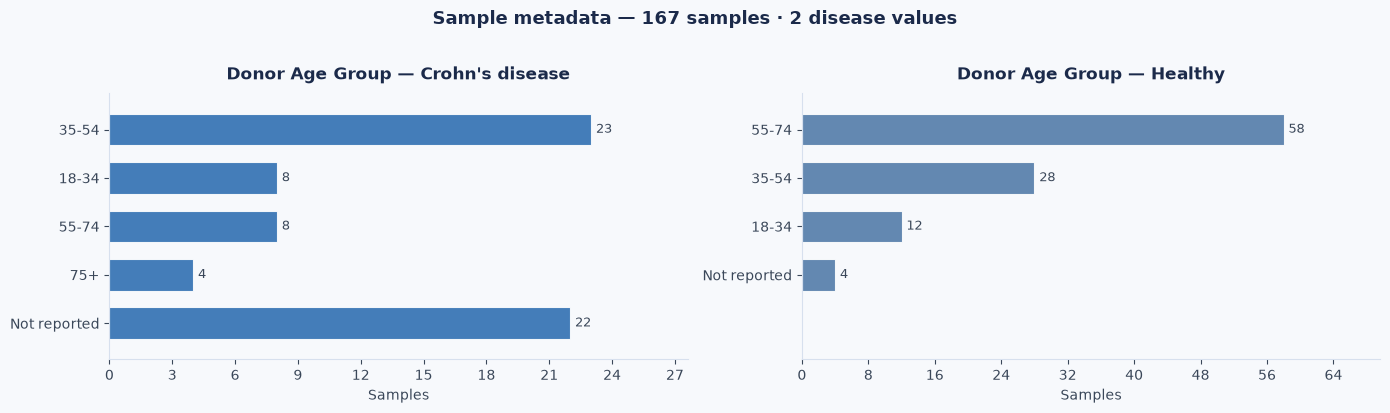

In [5]:
def get_sample_metadata(api_client, **kwargs):
    """
    Get sample metadata.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call,
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.

    Returns:
    - metadata_df (pd.DataFrame): Biosample metadata.
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # get sample metadata
    sample_metadata = get_all_data(
        omics_api.omics_search_samples_as_user,
        returned_metadata_fields="original_data_included",
        **kwargs
    )
    samples_df = pd.DataFrame.from_dict([item['metadata'] for item in sample_metadata])

    return samples_df


# --- get sample metadata ---
with odm_timer('Retrieving sample metadata for case and control groups'):
    case_metadata = get_sample_metadata(api_client, **case_query_params)
    control_metadata = get_sample_metadata(api_client, **control_query_params)

# --- show summary statistics for combined metadata ---
metadata = pd.concat([case_metadata, control_metadata], ignore_index=True)
display_metadata_summary(metadata, drop_any_na_col=False)

# --- compare age distribution between case and control groups ---
plot_metadata_summary(
    metadata,
    group_attribute='Disease',
    count_attribute='Donor Age Group',
)

### 1.3 Explore expression metadata

Confirm which expression group(s) are linked to the selected study by cross-validating such attributes as assay type, normalization, gene annotation, source file, etc. This documents what ODM will use for downstream `differential_expression` calls.

In [6]:
def search_expression_groups_by_study(api_client, study_filter=None, study_query=None):
    """
    Get expression group metadata by study.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - study_filter (str): Filter by study metadata (key-value metadata pair(s)).
    - study_query (str): Search for study objects via a full-text query over all study metadata fields.

    Returns:
    - ex_groups_df (pd.DataFrame): Expression group(s) metadata.
    """
    study_api = odm_api.StudySPoTAsUserApi(api_client)
    ex_integration_api = odm_api.ExpressionIntegrationAsUserApi(api_client)

    # define query parameters
    assert study_filter or study_query, "Either study_filter or study_query must be provided"
    query_params = {}
    if study_filter:
        query_params['filter'] = study_filter
    if study_query:
        query_params['query'] = study_query

    # search studies
    study = study_api.search_studies_as_user(**query_params).data
    study_accessions = [item['genestack:accession'] for item in study]
    assert len(study_accessions) > 0, "No study found"

    # search expression groups
    ex_group_list = []
    for acc in study_accessions:
        ex_groups = ex_integration_api.get_expression_groups_by_study_as_user(
            id=acc,
            returned_metadata_fields="original_data_included",
        )
        ex_group_list.extend(ex_groups)

    # create dataframe
    ex_groups_df = pd.DataFrame([
        {'groupId_expression': item.item_id, **item.metadata}
        for item in ex_group_list
    ])

    return ex_groups_df


# --- get expression group metadata ---
with odm_timer('Retrieving expression group for selected study'):
    ex_metadata = search_expression_groups_by_study(api_client, study_filter=study_filter)

# --- show expression group metadata---
# print(f"Expression group attributes (full list): {', '.join(ex_metadata.columns.sort_values())}")
_selected_attributes = [
    'Assay Type', 'Data Class', 'Normalization Method', 'Sparsity Percentage Value', 
    'Total Number of Cells or Nuclei', 'Total Number of Features'
]
display_collapsible_table(
    "Expression group metadata (selected attributes)",
    ex_metadata[_selected_attributes].T.sort_index().to_html(header=False),
    open_by_default=True
)

Assay Type,scRNA-seq
Data Class,Single-cell transcriptomics
Normalization Method,"log1p(CP10K) — per-cell total scaled to 10,000 then natural log + 1"
Sparsity Percentage Value,94.03
Total Number of Cells or Nuclei,221900
Total Number of Features,18370


## Step 2 · Explore cell metadata and embeddings

**What cell types are present, how abundant are they, and does any labelled population look unresolved on the embedding?**

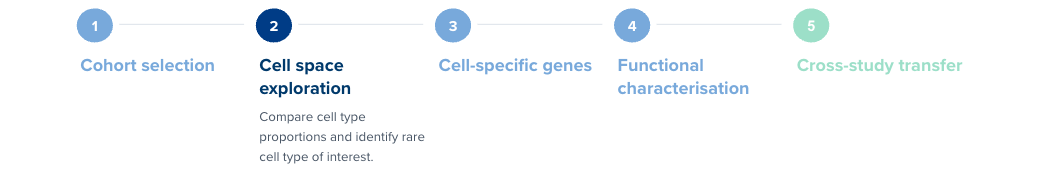

### 2.1 Get unique cell types

List distinct `cellType` values in the case cohort by iterative cell search. The resulting list drives composition plots and later per-type queries.

In [7]:
def get_cell_types(api_client, cell_type_attribute, cell_query=None, **kwargs):
    """
    List unique cell types from cell metadata.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - cell_type_attribute (str): Cell type attribute name.
    - cell_query (str): Base cell query (optional).
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call, 
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.

    Returns:
    - cell_types (list): List of unique cell types or empty list if no cells were found.
    """   
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # get the first value of cell types
    cell_metadata = omics_api.omics_search_cells_as_user(
        cell_query=cell_query,
        page_limit=1,
        **kwargs
    ).data
    if cell_metadata:
        cell_types = [cell_metadata[0][cell_type_attribute]]
    else:
        return []

    # extract cell types excluding already listed
    while True:
        cell_quote = '","'.join(cell_types)
        cell_type_query = f'"{cell_type_attribute}"!="{cell_quote}"'
        if cell_query:
            cell_type_query = f'{cell_type_query} AND {cell_query}'
        next_cells = omics_api.omics_search_cells_as_user(
            cell_query=cell_type_query,
            page_limit=1,
            **kwargs
        ).data
        if next_cells:
            cell_types.append(next_cells[0][cell_type_attribute])
        else:
            break

    return list(sorted(cell_types))


# --- get unique cell types ---
with odm_timer('Retrieving unique cell types'):
    cell_types_list = get_cell_types(
        api_client, 'cellType', **case_query_params
    )
print(f"Found {len(cell_types_list)} unique cell types")

Found 9 unique cell types


### 2.2 Explore cell type proportions

Use the `cell_ratio` analytical endpoint to count cells per type in case and control groups — proportions are computed in ODM, not by downloading cell tables. Compare compositions to see which populations expand, shrink, or remain rare.

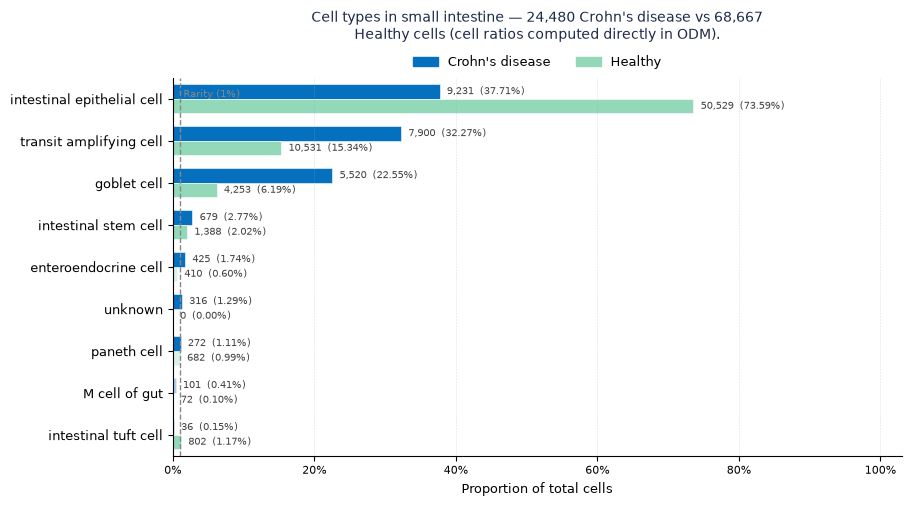

In [8]:
def get_cell_type_counts(api_client, cell_types, **kwargs):
    """
    Get cell counts for cell types.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - cell_types (list or dict): List of cell types or named dict of cell type queries.
    - **kwargs (dict): Optional keyword arguments for the `DERequestCaseGroup` request model, 
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.

    Returns:
    - df (pd.DataFrame): DataFrame with cell type counts.
    """
    analytics_api = odm_api.BETAAnalyticsOmicsQueriesAsUserApi(api_client)
    shared_params = camel_case_keys(kwargs)

    # define cell type queries dict
    cell_type_queries = (
        {cell_type: f'cellType="{cell_type}"' for cell_type in cell_types}
        if isinstance(cell_types, list)
        else cell_types
    )

    # iterate over cell types
    cell_type_counts_dict = {}
    for cell_type, cell_query in cell_type_queries.items():

        # retrieve cell type counts
        cr_response = analytics_api.cell_ratio_as_user(
            cr_request=CRRequest(
                cellGroup=DERequestCaseGroup(cellQuery=cell_query, **shared_params)
            )
        )
        cell_type_counts_dict[cell_type] = cr_response.count_selected

    # return as dataframe
    df = pd.DataFrame(
        list(cell_type_counts_dict.items()), 
        columns=['cell_type', 'total_count']
    )
    return df


# --- get cell type counts ---
with odm_timer('Counting cells per type in case and control groups'):
    cell_type_counts_case_df = get_cell_type_counts(
        api_client, cell_types_list, **case_query_params
    )
    cell_type_counts_control_df = get_cell_type_counts(
        api_client, cell_types_list, **control_query_params)

# --- plot cell type proportions ---
_total_case = int(cell_type_counts_case_df['total_count'].sum())
_total_ctrl = int(cell_type_counts_control_df['total_count'].sum())
_plot_title = (
    f"Cell types in {tissue_term} — {_total_case:,} {case_disease_term} "
    f"vs {_total_ctrl:,} {control_disease_term} cells "
    "(cell ratios computed directly in ODM)."
)
plot_cell_type_proportions_comparison(
    cell_type_counts_case_df,
    cell_type_counts_control_df,
    case_label=case_disease_term,
    ctrl_label=control_disease_term,
    title=_plot_title,
    legend_loc='top',
)

> **Reading this figure.**
>
> Paired bars show cell-type proportions in **Crohn's disease** (blue) vs **Healthy** (green). The **`unknown`** type is rare in disease samples and absent in healthy controls — a composition shift that motivates focusing on this population next.

### 2.3 Explore cell type heterogeneity

Retrieve high-quality cell metadata (using mitochondrial % and library-size filters) and plot UMAPs coloured by `cellType` for Crohn's disease and Healthy samples. Look for labelled types that form multiple neighbourhoods and compare them between conditions.

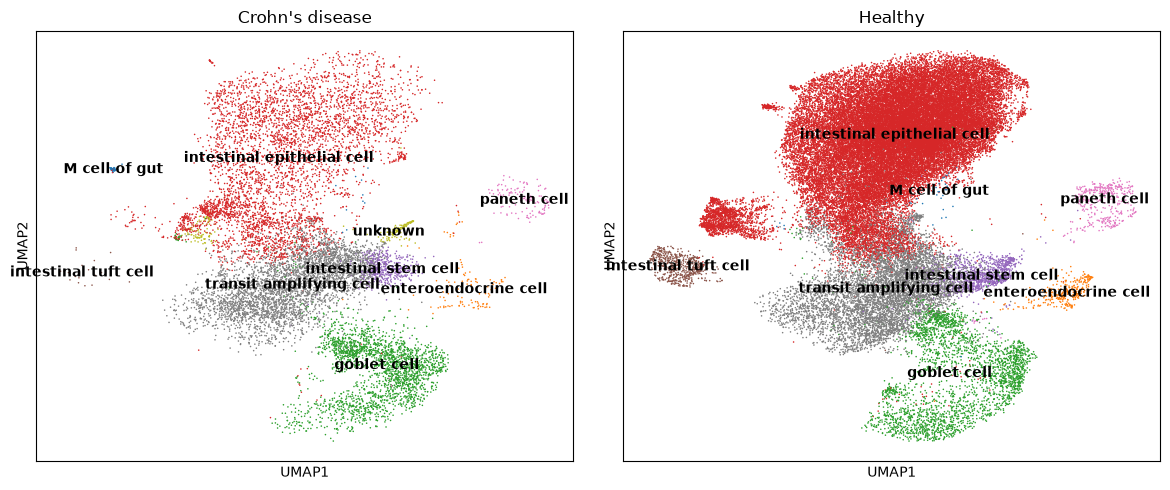

In [9]:
def get_single_cell_metadata(api_client, cell_query, **kwargs):
    """
    Get single-cell metadata for a given cell query.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - cell_query (str): Cell query.
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call, 
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.

    Returns:
    - adata (AnnData): AnnData object with single-cell metadata only.
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # query cell metadata
    cell_metadata = get_all_data(
        omics_api.omics_search_cells_as_user,
        cell_query=cell_query,
        **kwargs
    )
    cells_df = pd.DataFrame([item for item in cell_metadata])
    cells_df = cells_df.set_index("barcode")

    # create AnnData object
    adata = create_anndata_object(cell_metadata=cells_df)

    return adata


# --- define high-quality cell query ---
cell_types_filter = ' OR '.join([
    f'cellType="{cell_type}"' for cell_type in cell_types_list
])
cell_quality_filter = ' AND '.join([
    'percentMito < 20',
    '(nCounts > 1000 AND nCounts < 15000)'
])
all_cell_types_query = ' AND '.join([
    f'({cell_types_filter})',
    cell_quality_filter
])

# --- get object with cell metadata ---
with odm_timer('Retrieving single-cell metadata for case and control groups'):
    adata_case = get_single_cell_metadata(api_client, all_cell_types_query, **case_query_params)
    adata_control = get_single_cell_metadata(api_client, all_cell_types_query, **control_query_params)
adata_dict = {
    case_disease_term: adata_case,
    control_disease_term: adata_control
}

# --- show UMAPs with cell type labels ---
plot_umap_panel(adata_dict, color='cellType', point_size=5)

> **Reading this figure.**
>
> UMAPs coloured by `cellType` for Crohn's disease vs Healthy (quality-filtered cells). Most labelled types occupy similar regions in both panels; the **`unknown`** cluster stands out in disease and is the candidate rare population to isolate next.

### 2.4 Isolate the unknown cell type on UMAP

Subset to cells labelled `unknown` and inspect UMAP coordinates.

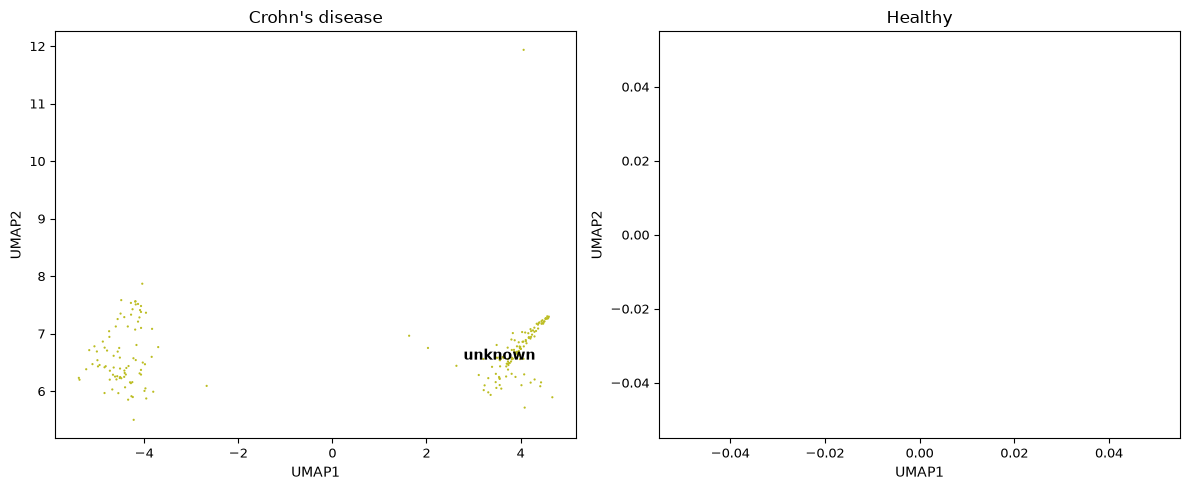

In [10]:
# filter anndata objects for 'unknown' cell type
unknown_adatas = {
    key: adata[adata.obs['cellType'] == 'unknown'].copy()
    for key, adata in adata_dict.items()
}

# show UMAPs of unknown cell types
plot_umap_panel(
    unknown_adatas, 
    color='cellType',
    point_size=10,
    show_umap_coords=True # explore cell type separation by UMAP coordinates
)

> **Reading this figure.**
>
> Only `unknown` cells are shown. Axis tick marks help choose a simple threshold (here, UMAP1 ≈ 0) that splits visually distinct neighbourhoods into queryable subtypes.

### 2.5 Set filter defining subtypes of "unknown" cell type

In this dataset, `unknown` cells separate along UMAP1 axis, so we turn that observation into reusable cell queries:

- `unknown` + quality filters + `umap.1 > 0` → candidate rare subtype  
- `unknown` + quality filters + `umap.1 <= 0` → the complementary unknown branch  
- all non-`unknown` cells → background for one-vs-rest marker discovery  

ODM cell queries can combine ontology-like labels with numeric embedding thresholds, so the subtype is defined server-side for all later analytical calls.

In [11]:
# define cell query for subtype of "unknown" cell type based on UMAP thresholding
umap_thresholds = [
    'umap.1 > 0', 
    'umap.1 <= 0'
]
cell_subtype_1_query = ' AND '.join([
    f'cellType="unknown"',
    cell_quality_filter,
    umap_thresholds[0]
])
cell_subtype_2_query = ' AND '.join([
    f'cellType="unknown"',
    cell_quality_filter,
    umap_thresholds[1]
])

# build cell query dict with "unknown" cell subtypes
cell_query_dict = {
    cell_type: f'cellType="{cell_type}" AND {cell_quality_filter}' 
    for cell_type in cell_types_list
    if cell_type != 'unknown'
}
cell_query_dict = {
    **cell_query_dict,
    'unknown_UMAP1>0': cell_subtype_1_query,
    'unknown_UMAP1<=0': cell_subtype_2_query
}

## Step 3 · Define cell-specific genes

**Which genes mark the rare subtype, and how specific are they versus other cell types?**

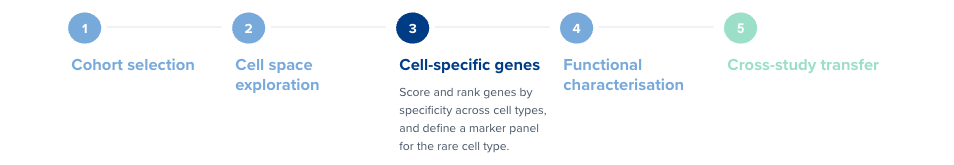

### 3.1 Set function for retrieving differential expression statistics

We use the `differential_expression` analytical endpoint to support specificity scoring (one-vs-rest against other cell types).

In [12]:
def run_single_cell_de_analysis(
    api_client, case_group_params, control_group_params, ex_query=None
):
    """
    Run differential expression analysis for a given case and control group.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - case_group_params (dict): Case group parameters for the `DERequestCaseGroup` request model,
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.
    - control_group_params (dict): Control group parameters for the `DERequestCaseGroup` request model,
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.
    - ex_query (str): Features to query (e.g. 'feature=MKI67,TOP2A').

    Returns:
    - pd.DataFrame: DE results.
    """
    analytics_api = odm_api.BETAAnalyticsOmicsQueriesAsUserApi(api_client)
    case_group_params = camel_case_keys(case_group_params)
    control_group_params = camel_case_keys(control_group_params)

    # retrieve differential expression results
    offset = 0
    limit = 20000
    de_response_list = []
    while True:
        de_response = analytics_api.differential_expression_as_user(
            de_request=DERequest(
                caseGroup=DERequestCaseGroup(**case_group_params),
                controlGroup=DERequestCaseGroup(**control_group_params),
                exQuery=ex_query,
                limit=limit,
                offset=offset
            )
        )
        offset = offset + limit
        
        # generate and format data frame
        df = pd.DataFrame(item.model_dump() for item in de_response.results_per_gene)
        de_response_list.append(df)
        
        if len(de_response.results_per_gene) < limit:
            break

    # combine all results into a single table
    de_results_df = pd.concat(de_response_list, ignore_index=True)

    return de_results_df

### 3.2 Set function for genome-wide cell type specificity scoring

The cell-specificity score $Spec_{g,ct}$ is calculated for each gene $g$ and cell type $ct$ as follows:

$$
Spec_{g,ct} = \mathrm{log2FC}_{g,ct} \cdot \Delta p_{g,ct}
$$

where $\mathrm{log2FC}_{g,ct}$ is the one-vs-rest log2 fold-change from DE, and $\Delta p_{g,ct}$ is the difference in the proportion of cells expressing gene $g$:

$$
\Delta p_{g,ct} = \frac{n_{g,ct}}{N_{ct}} - \frac{n_{g,\mathrm{rest}}}{N_{\mathrm{rest}}}
$$

Here $n_{g,ct}$ ($n_{g,\mathrm{rest}}$) is the number of cells expressing $g$ in type $ct$ (in all other types), and $N_{ct}$ ($N_{\mathrm{rest}}$) is the corresponding total cell count.

If $\mathrm{log2FC}_{g,ct}$ and $\Delta p_{g,ct}$ have opposite signs (or either is zero), the score is set to $0$.

In [13]:
def screen_genes_for_cell_type_specificity(
    api_client, cell_query_dict, min_expr_value=1, min_cell_count=2, **kwargs
):
    """
    Performs genome-wide cell type specificity scoring using one-vs-rest DE analysis.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - cell_query_dict (dict): Dictionary of queries for the whole cell type universe.
    - min_expr_value (int): Minimum expression value for a gene to be included in DE analysis.
    - min_cell_count (int): Minimum cell count for a gene to be included in the final results.
    - **kwargs (dict): Optional keyword arguments for the `DERequestCaseGroup` request model, 
        e.g. `{'sampleFilter': 'Organism="Homo sapiens"'}`.

    Returns:
    - pd.DataFrame: Results table with cell-specificity scores added for each gene and cell type.
    """
    shared_params = camel_case_keys(kwargs)

    # total cell counts per cell type (denominators for cell proportions)
    cell_type_counts_df = get_cell_type_counts(api_client, cell_query_dict, **shared_params)
    total_counts = cell_type_counts_df.set_index('cell_type')['total_count']
    all_cells_count = total_counts.sum()

    # iterate over cell types
    de_results_list = []
    for cell_type, cell_type_query in cell_query_dict.items():

        # define other cells query
        other_cells_query = ' OR '.join(
            query for ct, query in cell_query_dict.items() if ct != cell_type
        )

        # run DE analysis
        de_one_vs_rest_df = run_single_cell_de_analysis(
            api_client,
            case_group_params={'cellQuery': cell_type_query, **shared_params},
            control_group_params={'cellQuery': other_cells_query, **shared_params},
            ex_query=f'value>={min_expr_value}'
        )
        de_one_vs_rest_df['cell_type'] = cell_type
        de_results_list.append(de_one_vs_rest_df)

    # take mean expression, cell counts and log2FC from the DE output
    rename_columns = {
        'case_cell_count': 'cell_count',
        'control_cell_count': 'cell_count_rest',
        'case_avg_ex': 'mean',
        'control_avg_ex': 'mean_rest',
        'log2_fc': 'log2_fold_change',
    }
    spec_df = (
        pd.concat(de_results_list, ignore_index=True)
        .rename(columns=rename_columns)
        .dropna(subset=['log2_fold_change'])
        .loc[:, ['gene_id', 'cell_type'] + [col for col in rename_columns.values()]]
    )

    # remove genes with expression in few cells
    spec_df = spec_df[spec_df['cell_count'] >= min_cell_count]

    # add cell proportion difference
    spec_df['total_count'] = spec_df['cell_type'].map(total_counts)
    spec_df['cell_prop'] = spec_df['cell_count'] / spec_df['total_count']
    spec_df['cell_prop_rest'] = (
        spec_df['cell_count_rest'] / (all_cells_count - spec_df['total_count'])
    )
    spec_df['cell_prop_diff'] = spec_df['cell_prop'] - spec_df['cell_prop_rest']

    # cell-specificity scoring (only genes with concordant log2FC and proportion difference)
    lfc = spec_df['log2_fold_change']
    diff = spec_df['cell_prop_diff']
    concordant = (np.sign(lfc) == np.sign(diff)) & (lfc != 0) & (diff != 0)
    spec_df['cell_spec_score'] = np.where(
        concordant, np.sign(lfc) * lfc.abs() * diff.abs(), 0.0
    )

    # sort by cell-specificity score and cell proportion difference (for zero scores)
    return spec_df.sort_values(
        ['cell_spec_score', 'cell_prop_diff'], 
        ascending=False, 
        ignore_index=True
    )

### 3.3 Filter subtype-leading genes for a compact marker panel

Screen genome-wide cell specificity scores across all cell types in the case cohort and retain genes that most clearly distinguish `unknown_UMAP1>0`. To build a compact and interpretable marker panel (i.e. for cross-dataset rare subtype screening), keep genes where:

1. Target cell type ranks first (`is_top` condition in the notebook code).
2. Its specificity score exceeds 0.1 (`spec_threshold`).
3. The `gap` between the top and the next-best cell type exceeds the cross-cell-type score standard deviation (`spread`) twice (`spread_k`). 

This focuses the marker set on genes with stronger subtype preference and better separation from competing cell types. The dot plot below summarizes the selected markers across cell types by specificity, mean expression, and expressing fraction.

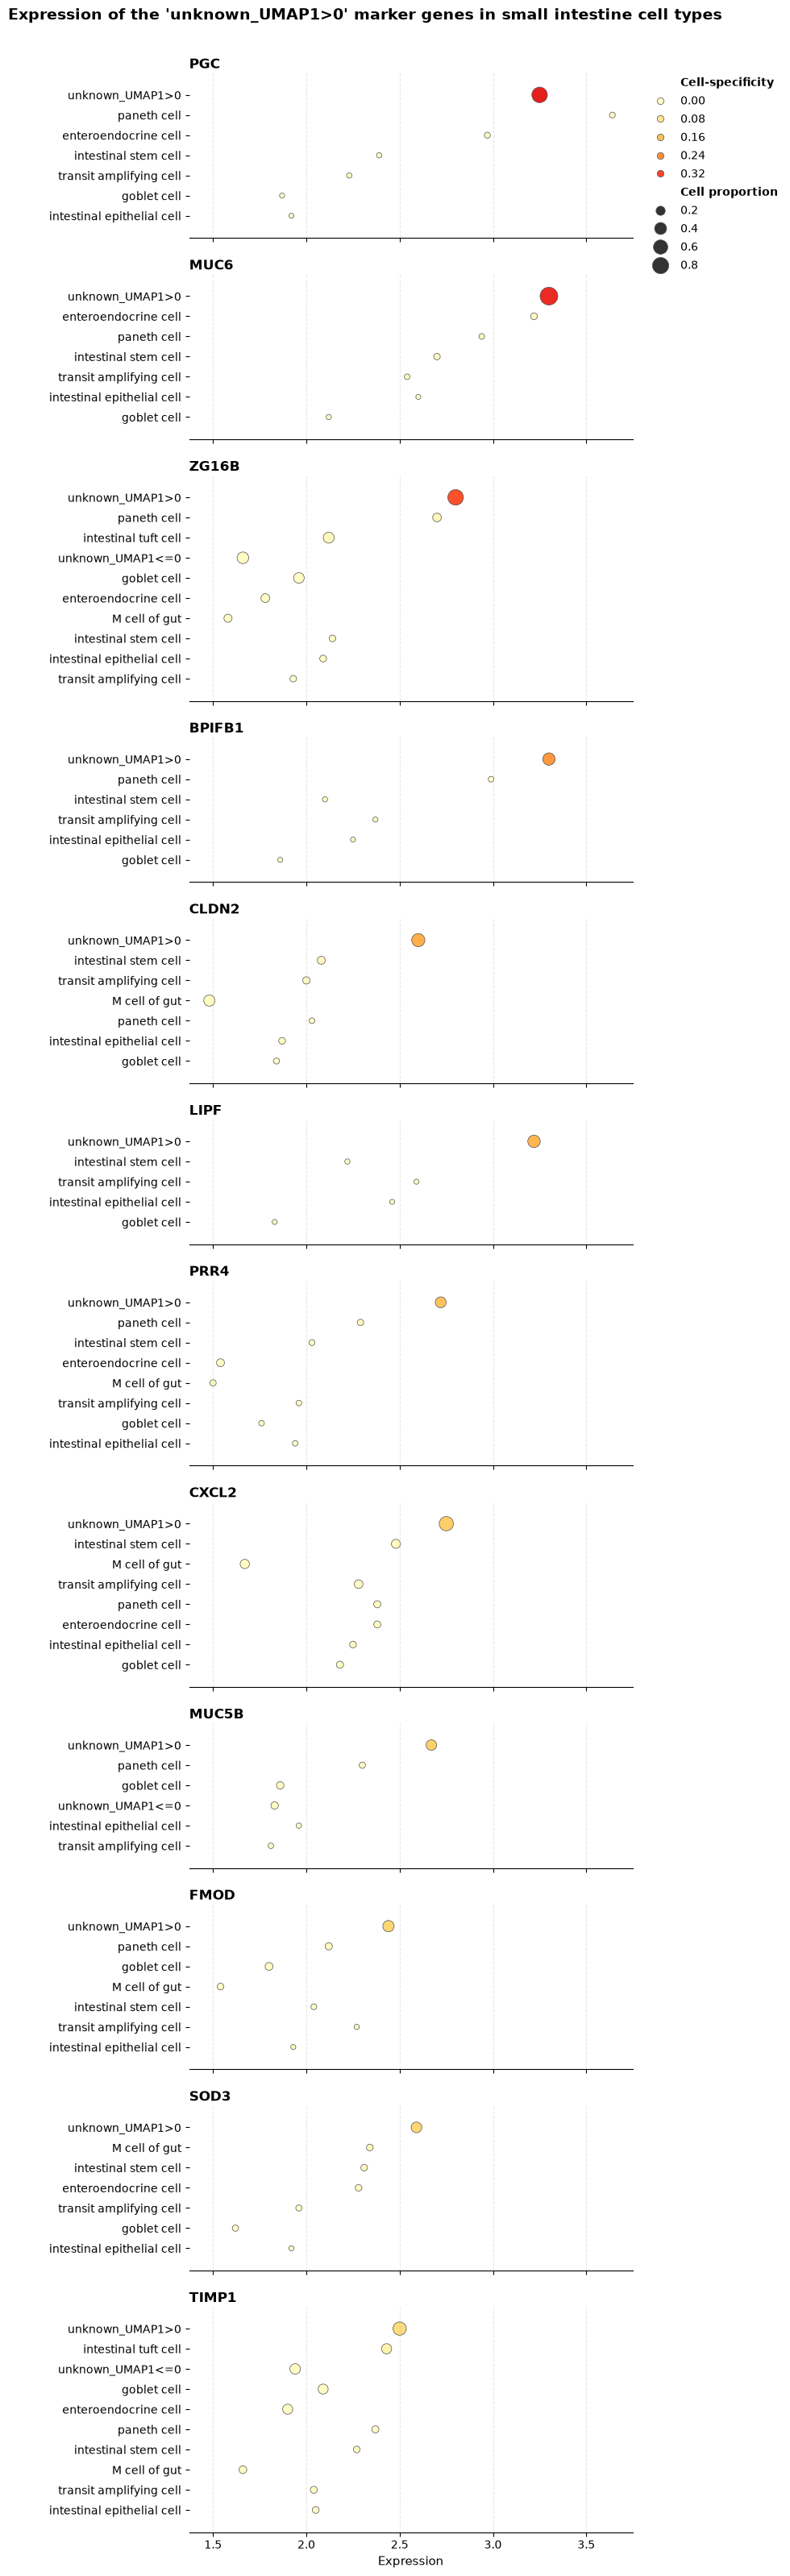

In [14]:
# find cell type specific genes
with odm_timer('Genome-wide cell type specificity scoring'):
    specificity_df = screen_genes_for_cell_type_specificity(
        api_client, 
        cell_query_dict, 
        min_expr_value=1, 
        min_cell_count=3,
        **case_query_params
    )

# define marker panel for the 'unknown_UMAP1>0' cell subtype
spec_threshold = 0.1
spread_k = 2
marker_panel_subtype_1 = (
    specificity_df
    .sort_values('cell_spec_score', ascending=False, kind='stable')
    .assign(
        is_top=lambda d: d.groupby('gene_id', sort=False).cumcount().eq(0),
        gap=lambda d: d.groupby('gene_id', sort=False)['cell_spec_score'].diff(-1),
        spread=lambda d: d.groupby('gene_id', sort=False)['cell_spec_score'].transform('std'),
    )
    .query(
        'is_top and cell_type == "unknown_UMAP1>0" '    # filter 1
        'and cell_spec_score > @spec_threshold '        # filter 2
        'and gap > @spread_k * spread'                  # filter 3
    )
    ['gene_id'].tolist()
)

# plot marker panel expression across the cell types
plot_sc_dotplot_and_cell_summary(
    df=specificity_df[specificity_df['gene_id'].isin(marker_panel_subtype_1)],
    plot_title="Expression of the 'unknown_UMAP1>0' marker genes in small intestine cell types",
    log1p_x=False
)

> **Reading this figure.**
>
> Rows are cell types (including unknown UMAP subtypes). **Dot size** = proportion of cells expressing the gene, **X-axis** = mean expression, **dot colour** = specificity score. Specificity reflects how much a gene stands out (higher level and higher % expressing) in one cell type versus all others combined.

### 3.4 Visualize cell subtype-specific genes on UMAP

Retrieve expression for the marker panel genes for all high-quality cells in case and control, then overlay each gene on UMAP. Confirm that marker signal concentrates in the same embedding neighbourhood used to define the subtype query.

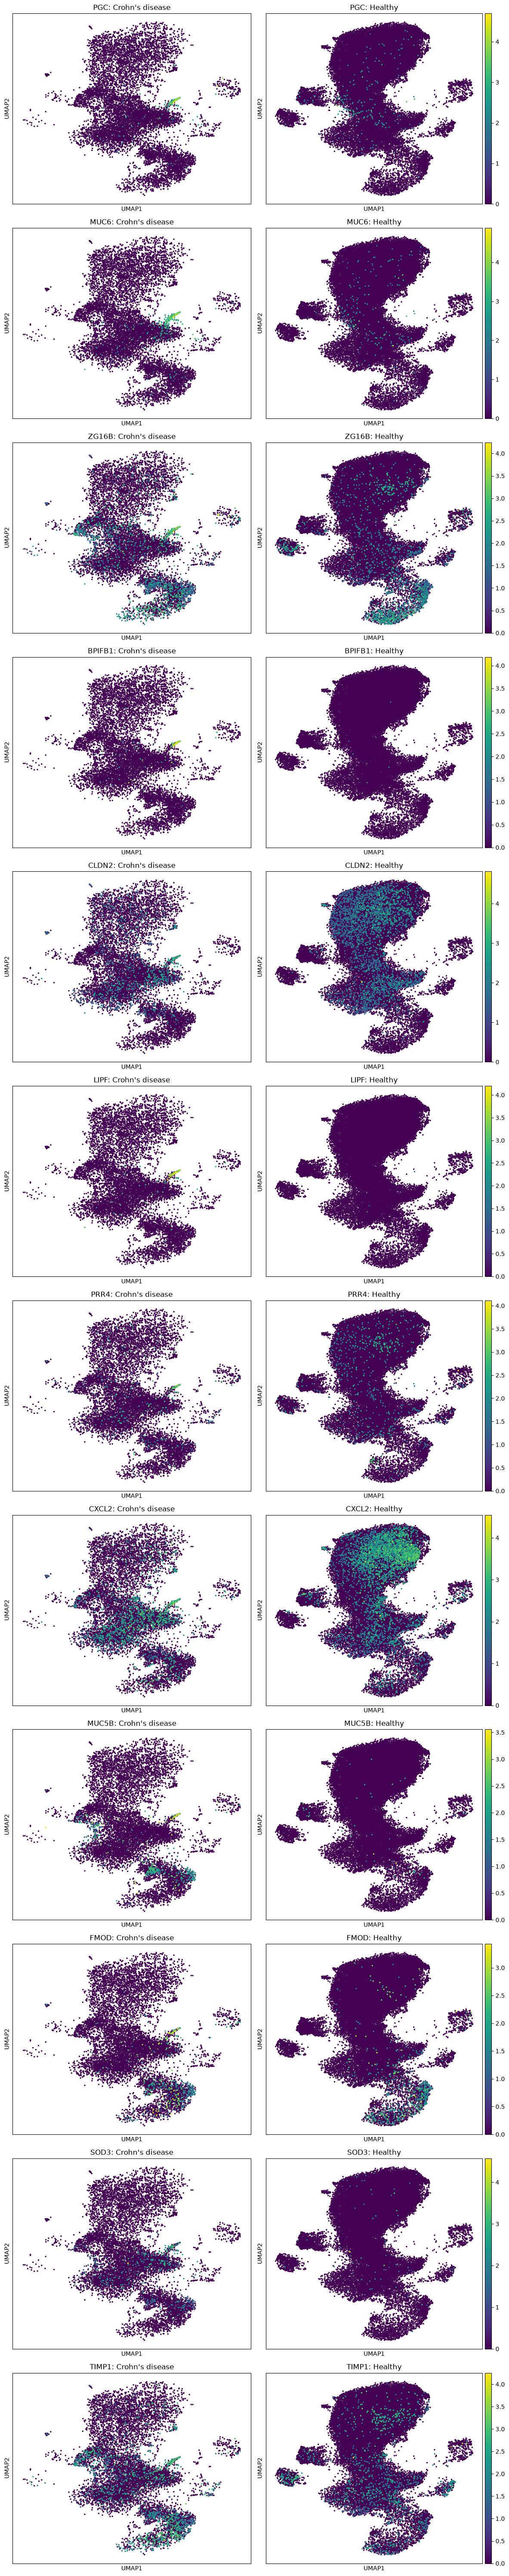

In [15]:
def get_single_cell_expression_data(api_client, genes, cell_query, **kwargs):
    """
    Get single-cell expression data for a given cell query and expression query.

    Parameters:
    - api_client (odm_api.ApiClient): API client instance.
    - genes (list): List of gene names.
    - cell_query (str): Cell query.
    - **kwargs (dict): Optional keyword arguments for the 'omics_search' API call, 
        e.g. `{'sample_filter': 'Organism="Homo sapiens"'}`.

    Returns:
    - adata (AnnData): AnnData object with single-cell expression data.
    """
    omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

    # query cell metadata
    cell_metadata = get_all_data(
        omics_api.omics_search_cells_as_user,
        cell_query=cell_query,
        **kwargs
    )
    cells_df = pd.DataFrame([item for item in cell_metadata])
    cells_df = cells_df.set_index("barcode")

    # query single-cell expression data
    ex_data = get_all_data(
        omics_api.omics_search_cells_expression_data_as_user,
        cell_query=cell_query,
        ex_query=f"feature={','.join(genes)}",
        **kwargs
    )
    ex_df = pd.DataFrame([item for item in ex_data])
    ex_df = clean_expression_metadata(ex_df)

    # create AnnData object
    counts_matrix = create_full_matrix(cells_df, ex_df, genes=genes)
    genes_unique = list(genes) if genes is not None else ex_df['feature_id'].unique()
    adata = create_anndata_object(
        cell_metadata=cells_df,
        feature_metadata=pd.DataFrame(index=genes_unique),
        counts_matrix=counts_matrix
    )

    return adata


# --- get single-cell expression data object ---
with odm_timer('Retrieving single-cell expression data for case and control groups'):
    adata_case = get_single_cell_expression_data(
        api_client, marker_panel_subtype_1, all_cell_types_query, **case_query_params
    )
    adata_control = get_single_cell_expression_data(
        api_client, marker_panel_subtype_1, all_cell_types_query, **control_query_params
    )
adata_dict = {
    case_disease_term: adata_case,
    control_disease_term: adata_control
}

# --- visualize expression of top cell subtype genes in case and control groups ---
compare_gene_expression_with_umap(adata_dict, marker_panel_subtype_1)

> **Reading this figure.**
>
> Each row is one top marker gene; columns compare disease vs healthy. Colour intensity reflects expression. Markers that light up the same UMAP region as `unknown_UMAP1>0` support the subtype definition. That pattern is clear for the cell-type-specific genes.

## Step 4 · Characterize rare cell type function

**What biology does the rare subtype look like, and does that match the original publication’s finer labels?**

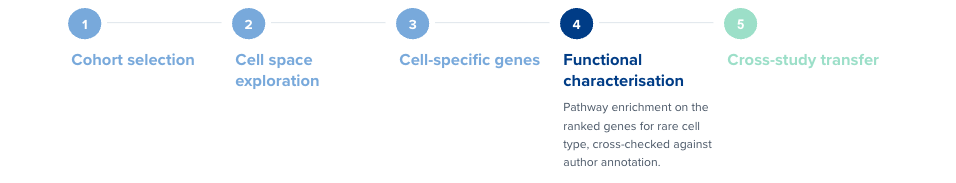

### 4.1 Pathway analysis

Run pre-ranked GSEA (MSigDB Hallmark) on genes ordered by cell-specificity score. Unlike the disease-vs-healthy comparison, enrichment here characterizes **what the rare subtype is** across every cell type.

Running pre-ranked GSEA for 'unknown_UMAP1>0' cell subtype...
Pathways (total): 50
Significant (FDR < 0.25)  : 5


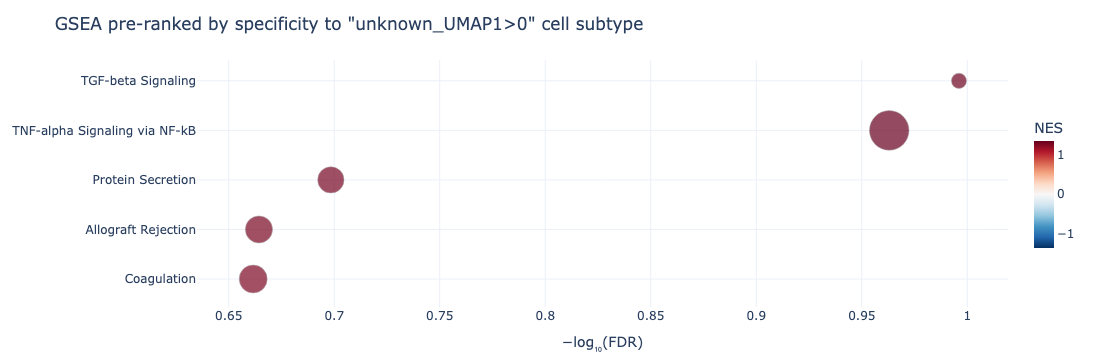

In [16]:
# run GSEA pre-ranked by cell specificity
print("Running pre-ranked GSEA for 'unknown_UMAP1>0' cell subtype...")
with open(os.devnull, 'w') as devnull, \
    contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
    subtype_1_specificity_df = specificity_df[specificity_df['cell_type'].eq('unknown_UMAP1>0')]
    gsea_results = run_gsea_per_cell_type(
        input_dict={'unknown_UMAP1>0': subtype_1_specificity_df},
        rank_by='cell_spec_score',
        gene_sets='MSigDB_Hallmark_2020',
        permutation_num=1000, 
        fdr_thresh=0.25
    )
print(f"Pathways (total): {len(gsea_results)}")
print(f"Significant (FDR < 0.25)  : {int(gsea_results['significant'].sum())}")

# interactive GSEA bubble plot
plot_gsea_bubble(
    gsea_results,
    cell_type='unknown_UMAP1>0',
    title='GSEA pre-ranked by specificity to "unknown_UMAP1>0" cell subtype'
)

> **Reading this figure.**
>
> Rows are Hallmark pathways enriched among genes specific to `unknown_UMAP1>0`. **Dot size** = number of leading-edge genes, **X-axis** = negative log10-transformed FDR, **dot colour** = normalized enrichment score (NES).
>
> This plot is interactive: hover over a dot to see a pop-up with GSEA result details (including the leading edge genes).

### 4.2 Show author annotation from original publication

Colour the same `unknown` cells by the authors’ finer label (`level3Annot`). This closes the loop: the embedding-defined subtype and its ODM-derived markers should correspond to a biologically named rare population in the source study (in this literature example, inflammatory epithelial cells or `INFLARE`).

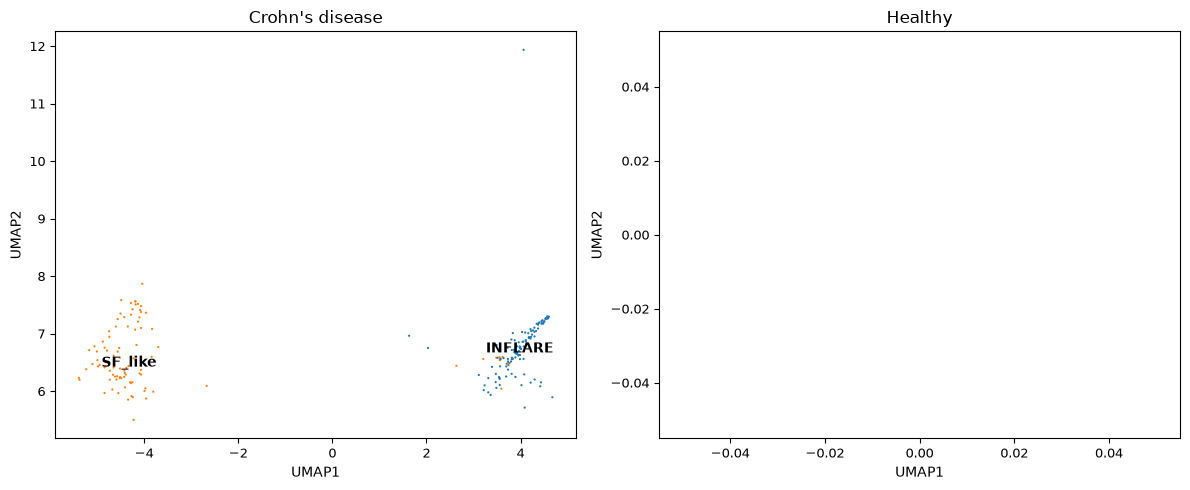

In [17]:
# plot UMAP with author's annotation of cell types
plot_umap_panel(
    unknown_adatas, 
    color='level3Annot',
    point_size=10,
    show_umap_coords=True
)

> **Reading this figure.**
>
> Same unknown cells as in Step 2.4, now coloured by author annotation instead of the coarse `cellType="unknown"` label. Agreement between UMAP neighbourhoods, marker genes, and author labels is the validation check for the discovery workflow.

## Step 5 · Find similar cells in another dataset

**Does the marker panel recover a similar epithelial state in an independent IBD study, and does that signature track clinical features?**

The compact panel from Step 3 is treated as a transferable `INFLARE` cell signature. We keep the same disease / tissue / assay sample filters, point them at a second study, score epithelial cells, and join the per-sample panel score to clinico-pathological metadata already in ODM.

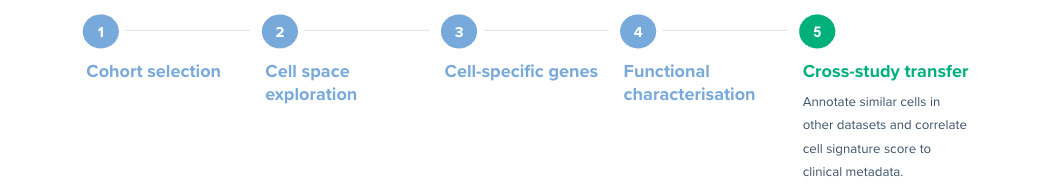

### 5.1 Select sample filters

Reuse `case_query_params` / `control_query_params` from Step 1 and only swap the study filter. That study’s sample metadata include clinical response and sampling timepoints.

In [18]:
# define new study filter
new_study_title = 'A longitudinal single-cell atlas of anti-tumour necrosis factor treatment in inflammatory bowel disease'
new_study_filter = f'"Study Title"="{new_study_title}"'

# define sample filters for new dataset using query parameters from the first dataset
new_case_query_params = case_query_params.copy()
new_control_query_params = control_query_params.copy()
new_case_query_params['study_filter'] = new_study_filter
new_control_query_params['study_filter'] = new_study_filter

### 5.2 Explore sample metadata

Pull biosample metadata for the new case and control groups with the reused filters, then explore metadata summary. Confirm that disease, tissue, and donor attributes still match the intended cohort, and that inflammation, treatment, response, and timepoint columns are present before scoring cells.

,not_na,total,mean,median,std_dev,min,max
Disease Duration,26,29,103.00,98.00,84.77,1.00,257.0
Donor Age,29,29,42.76,39.00,14.72,27.00,77.0
Inflammation Score,29,29,7.03,7.22,1.81,2.25,10.0


,not_na,unique,total,top_values
Cell Source,29,1,29,tissue
Clinical Response,29,3,29,Not applicable / True / False
Developmental Stage,29,1,29,human adult stage
Disease,29,2,29,Crohn's disease / Healthy
Disease Duration Unit,29,1,29,month
Donor Age Unit,29,1,29,year
Donor Ethnicity,29,1,29,Caucasian
Donor ID,29,16,29,CD1 / CD2 / CD3 / CD4 / CD8 / ...
Donor Remission Status,29,3,29,Remission / Non remission / None
Donor Sex,29,2,29,male / female


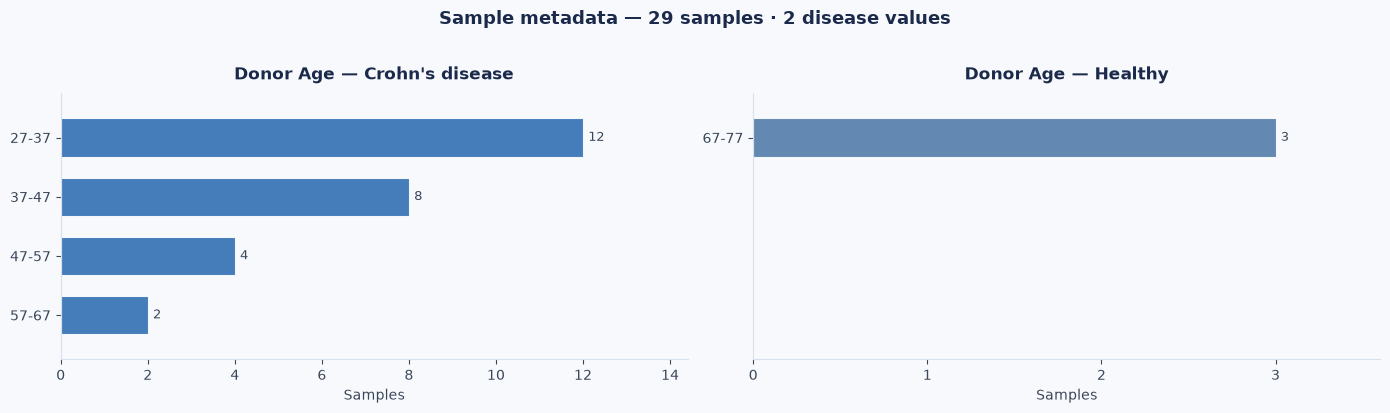

In [19]:
# get metadata for the samples in the new dataset
with odm_timer('Retrieving sample metadata for all case samples in the new dataset'):
    new_case_metadata = get_sample_metadata(api_client, **new_case_query_params)
    new_control_metadata = get_sample_metadata(api_client, **new_control_query_params)

# show summary statistics for sample metadata
new_study_metadata = pd.concat([new_case_metadata, new_control_metadata], ignore_index=True)
display_metadata_summary(new_study_metadata, drop_any_na_col=False)

# compare age distribution between case and control groups
plot_metadata_summary(
    new_study_metadata,
    group_attribute='Disease',
    count_attribute='Donor Age',
    bins=5
)

### 5.3 Explore annotation of cell subtypes in the new dataset
Only the `intestinal epithelial cell` type is shared between the first dataset’s cell type list and the `cellType` values in the new dataset. Finer annotation of ileal epithelium cells in the new study is under `detailedCellType` and `granularCellType` attributes. Here, for the rest of analysis steps we will use `detailedCellType`.

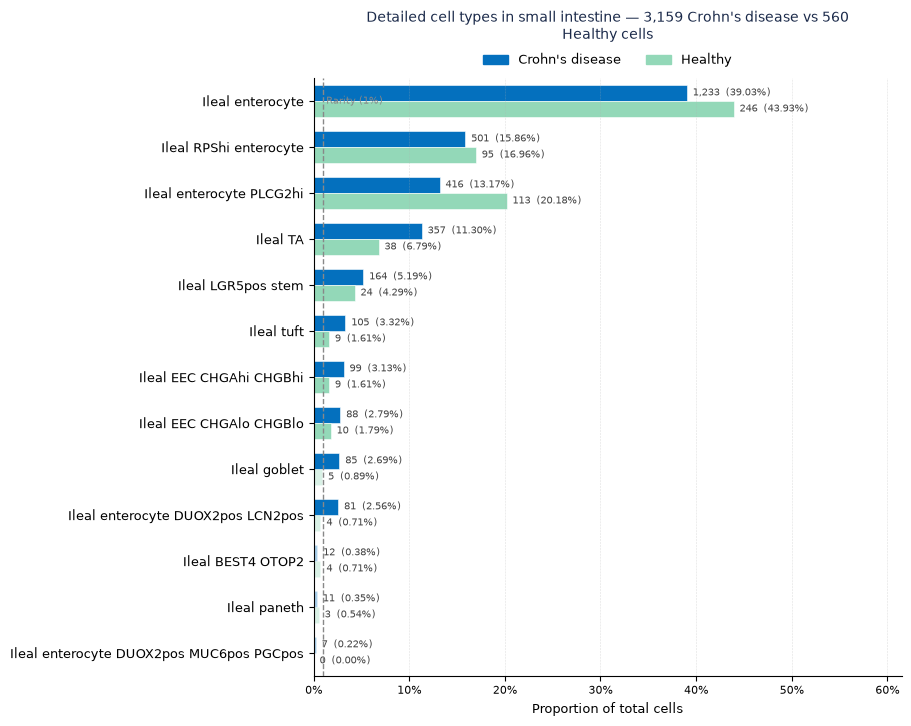

In [20]:
# define selected cell type query for the new dataset
selected_cell_type = 'intestinal epithelial cell'
selected_cell_type_query = ' AND '.join([
    f'cellType="{selected_cell_type}"',
    cell_quality_filter
])

# get unique detailed cell types
with odm_timer('Retrieving unique detailed cell types in the new dataset'):
    detailed_cell_types_list = get_cell_types(
        api_client,
        cell_type_attribute='detailedCellType',
        cell_query=selected_cell_type_query,
        **new_case_query_params
    )

# define detailed cell type queries
detailed_cell_query_dict = {
    cell_type: f'detailedCellType="{cell_type}" AND {cell_quality_filter}' 
    for cell_type in detailed_cell_types_list
}

# get detailed cell type counts
with odm_timer('Counting cells per detailed cell type in the new dataset'):
    cell_type_counts_new_case_df = get_cell_type_counts(
        api_client, detailed_cell_query_dict, **new_case_query_params
    )
    cell_type_counts_new_control_df = get_cell_type_counts(
        api_client, detailed_cell_query_dict, **new_control_query_params)

# plot detailed cell type proportions
_total_case = int(cell_type_counts_new_case_df['total_count'].sum())
_total_ctrl = int(cell_type_counts_new_control_df['total_count'].sum())
_plot_title = (
    f"Detailed cell types in {tissue_term} — {_total_case:,} {case_disease_term} "
    f"vs {_total_ctrl:,} {control_disease_term} cells "
)
plot_cell_type_proportions_comparison(
    cell_type_counts_new_case_df,
    cell_type_counts_new_control_df,
    case_label=case_disease_term,
    ctrl_label=control_disease_term,
    title=_plot_title,
    legend_loc='top',
)

> **Reading this figure.**
>
>  The new dataset has a much finer annotation of intestinal epithelial cell subtypes. Some labels already include the genes from the `INFLARE` signature panel, i.e. the `Ileal enterocyte DUOX2pos MUC6pos PGCpos` and `Ileal enterocyte DUOX2pos LCN2pos` with a contrasting difference in cell counts between the disease and healthy samples.

### 5.4 Score cells for the marker panel expression

Retrieve expression and calculate a per-cell panel score $Panel_c$ as a weighted sum of standardized expression values across genes in the INFLARE marker panel:

$$
Panel_c = \sum_{g \in G} w_g \, z_{gc}
$$

where $G$ is the set of marker genes, $w_g$ is the weight assigned to gene $g$ (set to $Spec_g$ for the *unknown_UMAP1>0* subtype from the discovery dataset), and $z_{gc}$ is the standardized expression of gene $g$ in cell $c$:

$$
z_{gc} = \frac{x_{gc} - \mu_g}{\sigma_g}
$$

Here $x_{gc}$ is the expression of gene $g$ in cell $c$, and $\mu_g$ and $\sigma_g$ are the mean and standard deviation of gene $g$ computed from the pooled expression values across all cells in the compared datasets.

Cells are then called marker-panel-positive if $Panel_c$ is above the chosen percentile of the score distribution among expressing cells (here, the *99.8th* percentile).

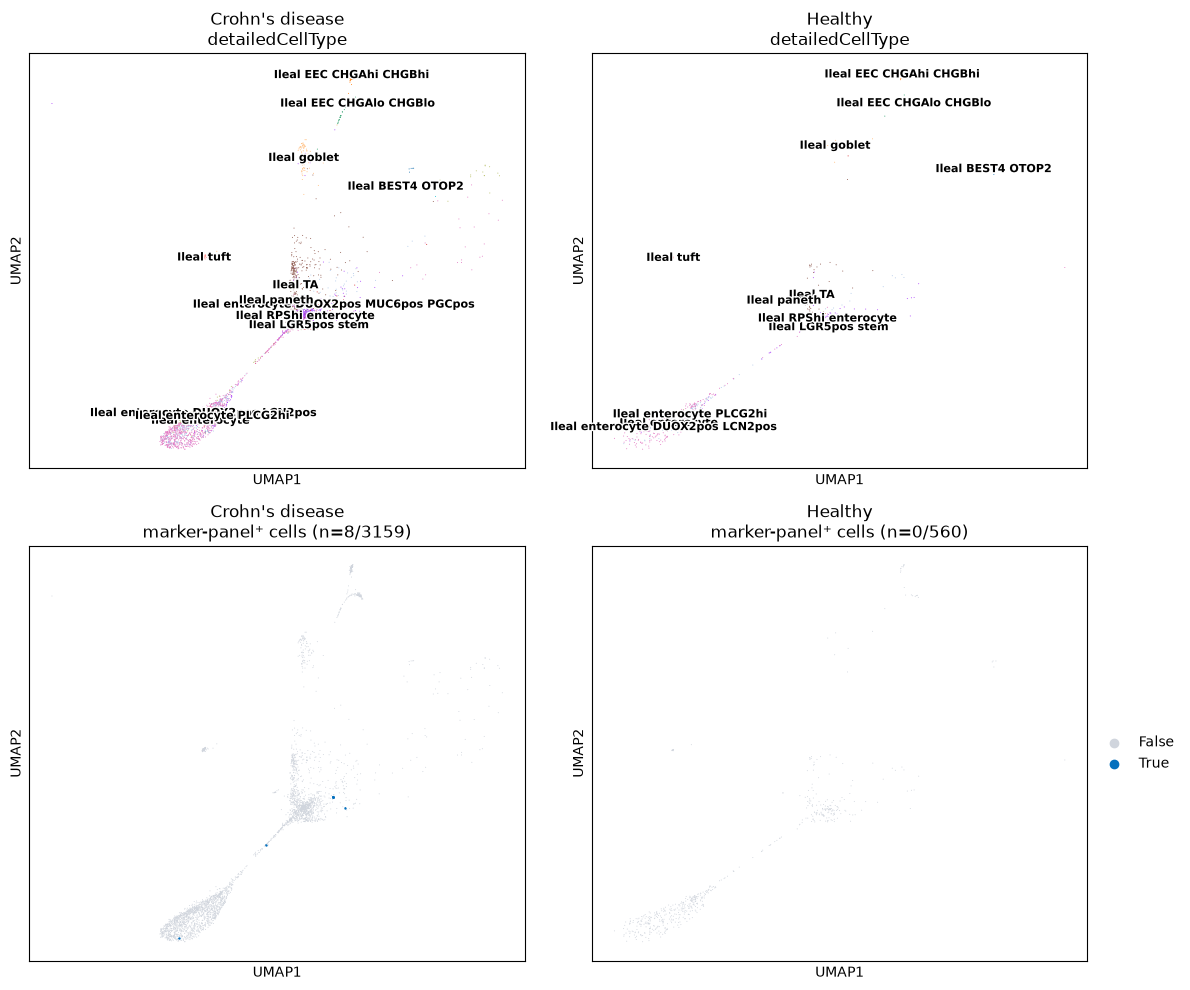

cell_type,count,total_count
Ileal enterocyte DUOX2pos MUC6pos PGCpos,5,7
Ileal LGR5pos stem,1,164
Ileal enterocyte,1,1233
Ileal enterocyte DUOX2pos LCN2pos,1,81


In [21]:
# get single-cell expression data object
with odm_timer('Retrieving single-cell expression data for cases and controls in the new dataset'):
    adata_new_case = get_single_cell_expression_data(
        api_client, marker_panel_subtype_1, selected_cell_type_query, **new_case_query_params
    )
    adata_new_control = get_single_cell_expression_data(
        api_client, marker_panel_subtype_1, selected_cell_type_query, **new_control_query_params
    )
adata_new_dict = {
    case_disease_term: adata_new_case,
    control_disease_term: adata_new_control
}

# score cells by weighted expression of marker panel genes (updates 'adata_new_dict' in place)
weights_dict = (
    subtype_1_specificity_df
    .set_index('gene_id')
    .loc[marker_panel_subtype_1, 'cell_spec_score']
    .to_dict()
)
annotate_cells_by_marker_panel(
    adata_dict=adata_new_dict,
    marker_genes=marker_panel_subtype_1,
    weights=weights_dict,
    score_percentile=99.8,
    cell_original_key='detailedCellType',
    point_size=2,
    copy=False
)

# explore detailed cell types annotated by the marker panel
marker_panel_cell_counts = (
    adata_new_case.obs.loc[
        adata_new_case.obs['marker_panel_cells'] == 'True',
        'detailedCellType'
    ]
    .value_counts()
    .rename_axis('cell_type')
    .reset_index()
    .query('count > 0')
    .merge(cell_type_counts_new_case_df, on='cell_type', how='left')
)
display_collapsible_table(
    "Detailed cell types annotated by the marker panel",
    marker_panel_cell_counts.to_html(index=False),
    open_by_default=True
)

> **Reading this figure and table.**
>
> Most panel-positive cells in disease belong to `Ileal enterocyte DUOX2pos MUC6pos PGCpos`. The signature built from the first study’s `unknown_UMAP1>0` subtype therefore lands on the independently named INFLARE-like enterocyte state.
>
> Besides, no cells were called in the `Healthy` samples which is in line with the original observation that INFLARE cells are attributed to the disease state.

### 5.5 Correlate the panel score with clinico-pathological parameters

Ask whether the transferred signature tracks disease activity and treatment context, using metadata already stored on the samples. Sum the per-cell panel scores $Panel_c$ within each sample $s$ to obtain a per-sample panel score $Panel_s$ (**INFLARE Cell Signature Score**):

$$
Panel_s = \sum_{c \in s} Panel_c
$$

Join $Panel_s$ onto case biosample metadata and correlate it with the **Inflammation Score**. Plot a scatter with a trend line, colour points by clinical response, and shape them by sample timepoint.

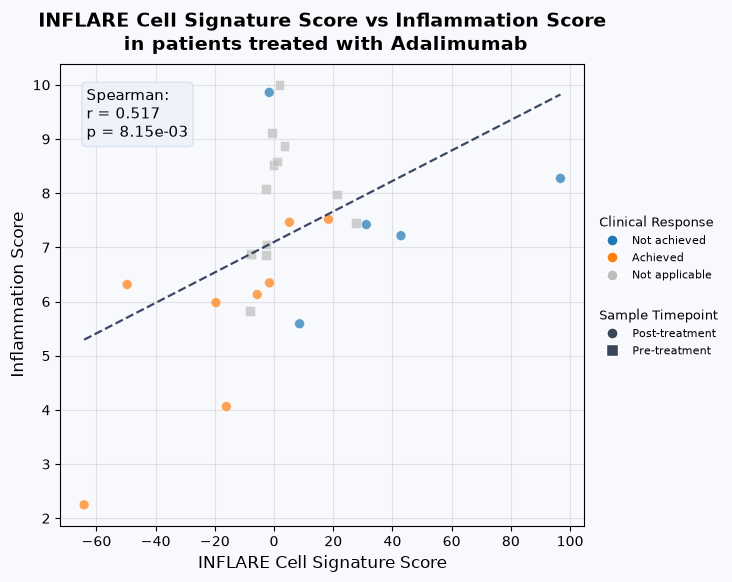

In [22]:
# add marker panel scores to sample metadata
marker_panel_scores_per_sample = (
    adata_new_case.obs
    .groupby(adata_new_case.obs['batch'])['marker_panel_score']
    .sum()
    .reset_index(name='INFLARE Cell Signature Score')
)
new_case_metadata = pd.merge(
    new_case_metadata,
    marker_panel_scores_per_sample, 
    left_on='Sample Source ID', 
    right_on='batch',
    how='left'
)

# show correlation between marker panel score and inflammation score
_col_x = 'INFLARE Cell Signature Score'
_col_y = 'Inflammation Score'
_treatment_compound = new_case_metadata['Treatment / Pharmaceutical Therapy Compound'].unique()[0]
_plot_title = f'{_col_x} vs {_col_y}\n in patients treated with {_treatment_compound}'
_col_shape = 'Sample Timepoint'
_col_color = 'Clinical Response'
_response_mapping = {True: "Achieved", False: "Not achieved"}
new_case_metadata[_col_color] = new_case_metadata[_col_color].map(_response_mapping)
plot_correlation_scatter(
    new_case_metadata,
    x=_col_x,
    y=_col_y,
    color_by=_col_color,
    shape_by=_col_shape,
    title=_plot_title,
    method='spearman',
)

> **Reading this figure.**
>
> Each point is a paired Crohn's disease sample. Marker **shape** is sample timepoint (pre- vs post-treatment); **colour** is clinical response (`Achieved` vs `Not achieved`).
>
> A positive association means samples with a higher INFLARE cell signature also have a higher inflammation score. In this plot that trend lines up with treatment outcome: non-responders sit toward higher signature score and higher inflammation, while patients who achieved response sit toward lower disease activity.

## Summary

This notebook showed how ODM supports rare-cell discovery as an interactive, query-driven workflow — without downloading full single-cell matrices:

1. **Cohort selection** with reusable metadata filters (study, disease, tissue, assay). Harmonised metadata makes it practical to define a clean case–control cohort and verify it before any cell-level analysis.
2. **Cell-space exploration** used server-side `cell_ratio` and cell-metadata queries to compare compositions and embeddings between conditions. Rare or poorly labelled populations can be turned into precise ODM cell queries (labels + quality filters + embedding thresholds) that stay defined for every later step.
3. **Marker discovery** via ove-vs-rest `differential_expression`, separating cell-identity signal from genes that belong more strongly to other named types. 
4. **Functional characterisation** with pathway enrichment and cross-checks against author cell annotations already in ODM.
5. **Cross-study transfer** of the same marker panel: score cells in an independent dataset, recover the matching finely labelled subtype, and correlate the per-sample signature with clinical features.

That combination — flexible filtering, server-side analytics, and metadata that travels with every query — is what makes complex single-cell hypotheses tractable directly on the platform.